In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

##Question 1: Read the dataframe, check null value if present then do the needful, check duplicate row , if present then do the needful.

In [50]:
df = pd.read_csv('spotify.csv')

In [51]:
df

,Artist,Track Name,Popularity,Duration (ms),Track ID
0,Drake,Rich Baby Daddy (feat. Sexyy Red & SZA),92,319191,1yeB8MUNeLo9Ek1UEpsyz6
1,Drake,One Dance,91,173986,1zi7xx7UVEFkmKfv06H8x0
2,Drake,IDGAF (feat. Yeat),90,260111,2YSzYUF3jWqb9YP9VXmpjE
3,Drake,First Person Shooter (feat. J. Cole),88,247444,7aqfrAY2p9BUSiupwk3svU
4,Drake,Jimmy Cooks (feat. 21 Savage),88,218364,3F5CgOj3wFlRv51JsHbxhe
...,...,...,...,...,...
435,French Montana,Splash Brothers,44,221863,3fBsEOnzwtlkpS0LxXAZhN
436,Fat Joe,All The Way Up (feat. Infared),64,191900,7Ezwtgfw7khBrpvaNPtMoT
437,A$AP Ferg,"Work REMIX (feat. A$AP Rocky, French Montana, ...",69,283693,7xVLFuuYdAvcTfcP3IG3dS
438,Diddy,Another One Of Me (feat. 21 Savage),65,220408,4hGmQboiou09EwhcTWa0H6


In [52]:
print("--- FIRST 5 ROWS ---")
df.head()


--- FIRST 5 ROWS ---


,Artist,Track Name,Popularity,Duration (ms),Track ID
0,Drake,Rich Baby Daddy (feat. Sexyy Red & SZA),92,319191,1yeB8MUNeLo9Ek1UEpsyz6
1,Drake,One Dance,91,173986,1zi7xx7UVEFkmKfv06H8x0
2,Drake,IDGAF (feat. Yeat),90,260111,2YSzYUF3jWqb9YP9VXmpjE
3,Drake,First Person Shooter (feat. J. Cole),88,247444,7aqfrAY2p9BUSiupwk3svU
4,Drake,Jimmy Cooks (feat. 21 Savage),88,218364,3F5CgOj3wFlRv51JsHbxhe


In [53]:
print("--- LAST 5 ROWS ---")
df.tail()

--- LAST 5 ROWS ---


,Artist,Track Name,Popularity,Duration (ms),Track ID
435,French Montana,Splash Brothers,44,221863,3fBsEOnzwtlkpS0LxXAZhN
436,Fat Joe,All The Way Up (feat. Infared),64,191900,7Ezwtgfw7khBrpvaNPtMoT
437,A$AP Ferg,"Work REMIX (feat. A$AP Rocky, French Montana, ...",69,283693,7xVLFuuYdAvcTfcP3IG3dS
438,Diddy,Another One Of Me (feat. 21 Savage),65,220408,4hGmQboiou09EwhcTWa0H6
439,Rick Ross,Stay Schemin,68,267720,0nq6sfr8z1R5KJ4XUk396e


In [54]:
df.columns

Index(['Artist', 'Track Name', 'Popularity', 'Duration (ms)', 'Track ID'], dtype='object')

In [55]:
df.sample(5)

,Artist,Track Name,Popularity,Duration (ms),Track ID
334,Lil Uzi Vert,XO Tour Llif3,83,182706,7GX5flRQZVHRAGd6B4TmDO
285,Playboi Carti,Location,81,168783,3yk7PJnryiJ8mAPqsrujzf
257,DaBaby,Ball If I Want To,70,112546,0cu0rhnlCnJ7JIeHRiLpj3
281,The Weeknd,Popular (with Playboi Carti & Madonna),85,215466,7GUhiAHLoVy1V8ucQuZ3CB
302,Flo Rida,Wild Ones (feat. Sia),82,232946,1NpW5kyvO4XrNJ3rnfcNy3


In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.describe(include='all')

In [ ]:
df.dtypes

In [ ]:
df.isnull().sum()

In [ ]:
print("--- TOTAL DUPLICATE ROWS ---")
print(df.duplicated().sum())

##Problems Identified:
- Hidden Whitespaces: Text features (Artist, Track Name, Track ID) contain unnoticeable leading and trailing spaces that prevent accurate string matching.

- Data Redundancy: The dataset contains 27 completely duplicate records where the exact same song (Track ID) is recorded multiple times, which will skew analysis metrics like mean popularity.

##Solution Strategy:
- String Trimming: Applied .str.strip() to eliminate all hidden whitespaces across the text columns to ensure clean, consistent values.

- Deduplication: Dropped all duplicate rows based on the unique Track ID using df.drop_duplicates(), preserving only the first occurrence (keep='first') to stabilize final counts.

In [ ]:
# 1. Strip hidden spaces
df['Artist'] = df['Artist'].str.strip()
df['Track Name'] = df['Track Name'].str.strip()
df['Track ID'] = df['Track ID'].str.strip()

# 2. Drop duplicates
df.drop_duplicates(subset=['Track ID'], keep='first', inplace=True)

# 3. Final verification of remaining clean rows
print(f"Remaining Clean Rows after Deduplication: {len(df)}")

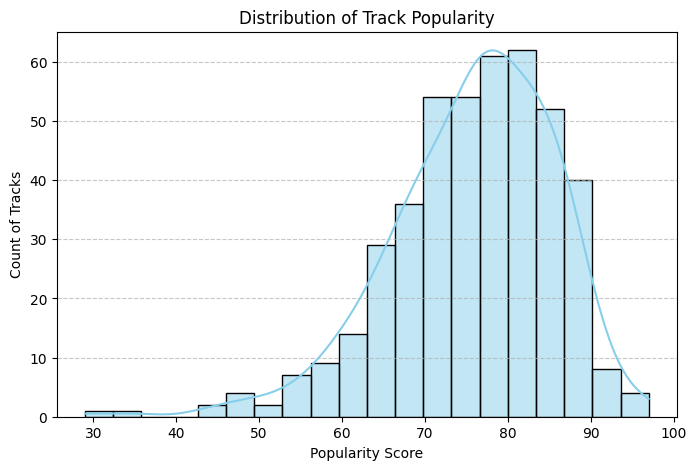

In [59]:
#Question 2: What is the distribution of popularity among the tracks in the dataset? Visualize it using a histogram.

# Setting up the plot dimensions for optimal visualization clarity
plt.figure(figsize=(8, 5))

# Generating the histogram with a smooth density curve (KDE) over the bins
sns.histplot(df['Popularity'], bins=20, kde=True, color='skyblue')

# Adding descriptive titles and labels for the viewer
plt.title('Distribution of Track Popularity')
plt.xlabel('Popularity Score')
plt.ylabel('Count of Tracks')

# Implementing a faint horizontal grid to assist in reading absolute track counts
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

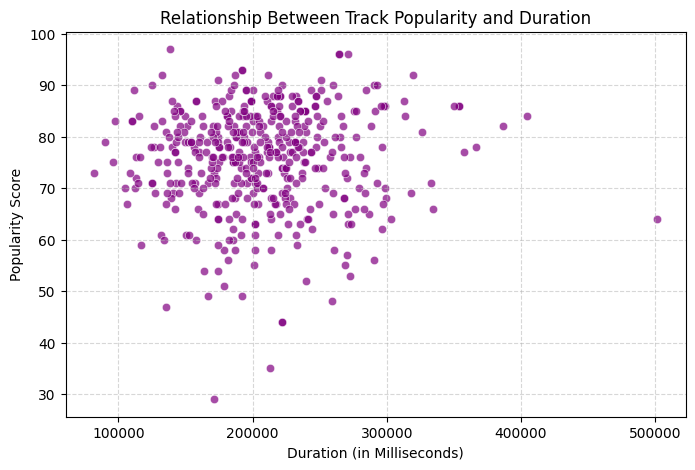

In [56]:
#Question 3: Is there any relationship between the popularity and the duration of tracks? Explore this using a scatter plot.

plt.figure(figsize=(8, 5))

# Plotting the variables; alpha=0.7 adds subtle transparency to highlight high-density overlap zones
sns.scatterplot(data=df, x='Duration (ms)', y='Popularity', color='purple', alpha=0.7)

# Structuring clear labels to make the relationship easily readable
plt.title('Relationship Between Track Popularity and Duration')
plt.xlabel('Duration (in Milliseconds)')
plt.ylabel('Popularity Score')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

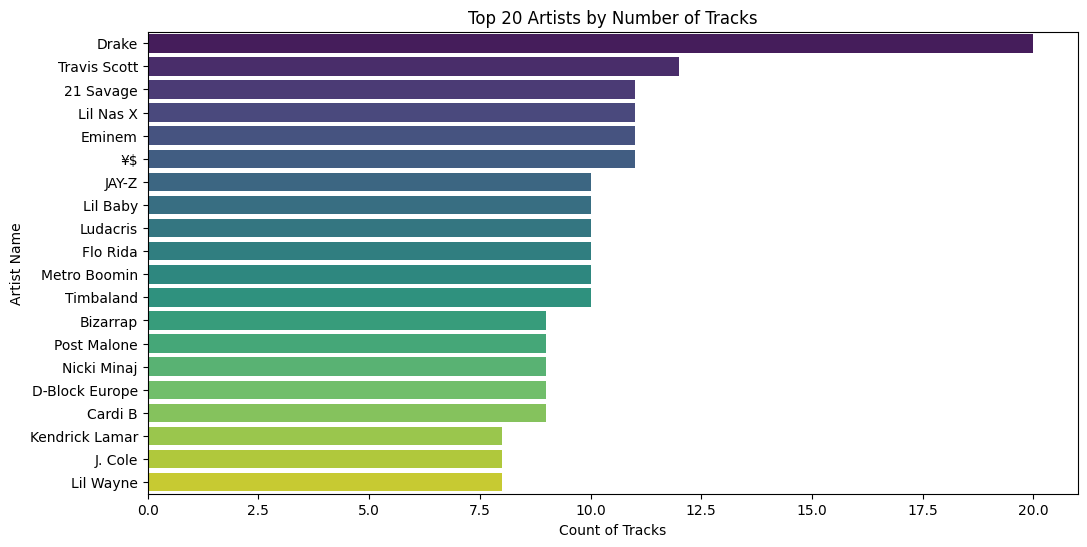

In [57]:
#Question 4: Which artist has the highest number of tracks in the dataset? Display the count of tracks for each artist using a countplot.

plt.figure(figsize=(12, 6))

# Extracting the top 20 most frequent artists to keep the visualization clean and descriptive
top_artists_order = df['Artist'].value_counts().index[:20]

# Generating a horizontal countplot so long artist names remain perfectly legible
sns.countplot(data=df[df['Artist'].isin(top_artists_order)], y='Artist', order=top_artists_order, palette='viridis')

plt.title('Top 20 Artists by Number of Tracks')
plt.xlabel('Count of Tracks')
plt.ylabel('Artist Name')
plt.show()

In [ ]:
#Question 5: What are the top 5 least popular tracks in the dataset? Provide the artist name and track name for each.


print("--- TOP 5 LEAST POPULAR TRACKS ---")

# Sorting the dataset by the 'Popularity' column in ascending order (lowest first)
least_popular = df.sort_values(by='Popularity', ascending=True).head(5)[['Artist', 'Track Name', 'Popularity']]

# Presenting the targeted subset showing exactly who and what scored the lowest
display(least_popular)

In [ ]:
#Question 6: Among the top 5 most popular artists, which artist has the highest popularity on average? Calculate and display the average popularity for each artist.

# Isolating the top 5 most frequent artists based on track occurrence counts
top_5_artists = df['Artist'].value_counts().head(5).index

# Grouping by these specific artists and calculating the mathematical mean of their popularity scores
avg_popularity = df[df['Artist'].isin(top_5_artists)].groupby('Artist')['Popularity'].mean().sort_values(ascending=False)

print("--- AVERAGE POPULARITY FOR TOP 5 ARTISTS ---")
print(avg_popularity)

In [ ]:
#Question 7: For the top 5 most popular artists, what are their most popular tracks? List the track name for each artist.

print("--- MOST POPULAR TRACKS FOR TOP 5 ARTISTS ---")

# Sorting the subset by popularity descending and selecting the first entry per artist group
top_tracks = df[df['Artist'].isin(top_5_artists)].sort_values(by='Popularity', ascending=False).groupby('Artist').first()[['Track Name', 'Popularity']]

display(top_tracks)

In [ ]:
#Question 8: Visualize relationships between multiple numerical variables simultaneously using a pair plot.

# Utilizing a pairplot across our primary numerical features to view interactions and individual densities simultaneously
sns.pairplot(df[['Popularity', 'Duration (ms)']], diag_kind='kde', height=3.5)

# Adding a comprehensive global title to the matrix layout
plt.suptitle('Pair Plot of Numerical Variables', y=1.02)
plt.show()

In [ ]:
#Question 9 Does the duration of tracks vary significantly across different artists? Explore this visually using a box plot or violin plot.


plt.figure(figsize=(10, 6))

# Generating a box plot to examine median, range, spread, and outlier points for track lengths across the top 5 artists
sns.boxplot(data=df[df['Artist'].isin(top_5_artists)], x='Artist', y='Duration (ms)', palette='Set2')

plt.title('Track Duration Variation Across Top 5 Artists')
plt.xlabel('Artist')
plt.ylabel('Duration (ms)')
plt.show()

In [ ]:
#Question 10- How does the distribution of track popularity vary for different artists? Visualize this using a swarm plot or a violin plot.


plt.figure(figsize=(10, 6))

# Layer 1: Plotting smooth violin density distributions to see the general shape of performance scores
sns.violinplot(data=df[df['Artist'].isin(top_5_artists)], x='Artist', y='Popularity', palette='Pastel1', inner=None)

# Layer 2: Overlaying explicit track points via stripplot to display the exact distribution density transparently
sns.stripplot(data=df[df['Artist'].isin(top_5_artists)], x='Artist', y='Popularity', color='black', alpha=0.5, size=5)

plt.title('Distribution of Track Popularity Variation Across Top 5 Artists')
plt.xlabel('Artist')
plt.ylabel('Popularity Score')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()